In [5]:
import numpy as np
from matplotlib import pyplot as plt        
from scipy.spatial.distance import pdist, squareform


In [6]:
X_train = np.load('preprocessing/X_train.npy')
X_val = np.load('preprocessing/X_val.npy')
X_test = np.load('preprocessing/X_test.npy')
y_train = np.load('preprocessing/y_train.npy')
y_val = np.load('preprocessing/y_val.npy')
y_test = np.load('preprocessing/y_test.npy')

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

Train: (2099, 13), Val: (450, 13), Test: (451, 13)


GA

In [7]:
from step1.RBF_model import *
import random

# chromosome = [num_centers, init_method, trainable_centers, trainable_sigma, sigma, learning_rate, batch_size]

num_centers_space = [25, 50, 75, 100, 150, 200, 300]
init_method_space = ['k-means', 'random_from_data', 'random_normal']
trainable_centers_space = [True, False]
trainable_sigma_space = [True, False]
sigma_space = ['auto', 0.5, 1.0, 2.0]
lr_space = [0.0005, 0.001, 0.005, 0.01]
batch_size_space = [16, 32, 64]


def create_random_chromosome():
    chromosome = [
        random.choice(num_centers_space),
        random.choice(init_method_space),
        random.choice(trainable_centers_space),
        random.choice(trainable_sigma_space),
        random.choice(sigma_space),
        random.choice(lr_space),
        random.choice(batch_size_space)
    ]

    return chromosome


def initialize_population(pop_size):
    population = []
    for _ in range(pop_size):
        chromosome = create_random_chromosome()
        population.append(chromosome)

    return population


def build_rbf_from_chromosome(chromosome, X_train, num_classes):
    """
    ساخت مدل RBF از روی کروموزوم الگوریتم ژنتیک
    """

    num_centers = chromosome[0]
    init_method = chromosome[1]
    trainable_centers = chromosome[2]
    trainable_sigma = chromosome[3]
    sigma_val = chromosome[4]

    centers = get_centers(init_method, num_centers, X_train)

    if sigma_val == 'auto':
        # محاسبه سیگما بر اساس فواصل مراکز (یک مقدار عددی جایگزین رشته 'auto' می‌شود)
        dists = pdist(centers)
        sigma_val = np.mean(dists) / np.sqrt(2 * num_centers)
        if sigma_val == 0: sigma_val = 1.0 # جلوگیری از صفر شدن

    model = RBFNetwork(
        num_inputs=X_train.shape[1],
        num_centers=num_centers,
        num_classes=num_classes,
        centers=centers,
        sigma=sigma_val, # حالا حتماً عدد است
        trainable_centers=trainable_centers,
        trainable_sigma=trainable_sigma
    )

    return model


def fitness_function(chromosome):
    model = build_rbf_from_chromosome(
        chromosome,
        X_train,
        num_classes=len(np.unique(y_train))
    )
    _, val_f1, _ = train_rbf(
        model,
        X_train, y_train,
        X_val, y_val,
        epochs=150,
        lr=chromosome[5],
        batch_size=chromosome[6],
        patience=15,
        verbose=False
    )

    return val_f1


def evaluate_population(population, X_train, y_train, X_val, y_val):
    fitness_scores = []

    for i, chromosome in enumerate(population):
        print(f"Evaluating Individual {i + 1}/{len(population)}...")

        fitness = fitness_function(chromosome)

        fitness_scores.append(fitness)
        print(f"Fitness (Macro-F1): {fitness:.4f}\n")

    return fitness_scores


def tournament_selection(population, fitness_scores, tournament_size=3):
    selected_indices = random.sample(range(len(population)), tournament_size)
    best_index = selected_indices[0]

    for idx in selected_indices:
        if fitness_scores[idx] > fitness_scores[best_index]:
            best_index = idx

    return population[best_index]


def crossover(parent1, parent2, crossover_rate=0.9):
    if random.random() > crossover_rate:
        return parent1.copy(), parent2.copy()

    child1 = []
    child2 = []

    for g1, g2 in zip(parent1, parent2):

        if random.random() < 0.5:
            child1.append(g1)
            child2.append(g2)
        else:
            child1.append(g2)
            child2.append(g1)

    return child1, child2


def mutate(chromosome, mutation_rate=0.1):
    if random.random() < mutation_rate:
        chromosome[0] = random.choice(num_centers_space)

    if random.random() < mutation_rate:
        chromosome[1] = random.choice(init_method_space)

    if random.random() < mutation_rate:
        chromosome[2] = random.choice(trainable_centers_space)

    if random.random() < mutation_rate:
        chromosome[3] = random.choice(trainable_sigma_space)

    if random.random() < mutation_rate:
        chromosome[4] = random.choice(sigma_space)

    if random.random() < mutation_rate:
        chromosome[5] = random.choice(lr_space)

    if random.random() < mutation_rate:
        chromosome[6] = random.choice(batch_size_space)

    return chromosome


def run_genetic_algorithm(population_size=30, generations=15, crossover_rate=0.8, mutation_rate=0.2, elitism=True):
    population = initialize_population(population_size)
    best_chromosome = None
    best_fitness = -1
    history = []

    for generation in range(generations):
        print(f"\n========== Generation {generation + 1}/{generations} ==========")

        fitness_scores = evaluate_population(population, X_train, y_train, X_val, y_val)
        best_index = np.argmax(fitness_scores)
        gen_best_chromosome = population[best_index]
        gen_best_fitness = fitness_scores[best_index]
        avg_fitness = np.mean(fitness_scores)

        history.append({
            "generation": generation + 1,
            "best_fitness": gen_best_fitness,
            "avg_fitness": avg_fitness,
            "best_chromosome": gen_best_chromosome
        })

        if best_fitness < gen_best_fitness:
            best_chromosome = gen_best_chromosome
            best_fitness = gen_best_fitness

        new_population = []
        if elitism:
            new_population.append(gen_best_chromosome.copy())

        while len(new_population) < population_size:
            parent1 = tournament_selection(population, fitness_scores)
            parent2 = tournament_selection(population, fitness_scores)

            child1, child2 = crossover(parent1, parent2, crossover_rate)
            child1 = mutate(child1, mutation_rate)
            child2 = mutate(child2, mutation_rate)

            new_population.append(child1.copy())
            if len(new_population) < population_size:
                new_population.append(child2.copy())

        population = new_population

    return best_chromosome, best_fitness, history



run GA


========== Generation 1/15 ==========
Evaluating Individual 1/30...
Fitness (Macro-F1): 0.2285

Evaluating Individual 2/30...
Fitness (Macro-F1): 0.2222

Evaluating Individual 3/30...
Fitness (Macro-F1): 0.8917

Evaluating Individual 4/30...
Fitness (Macro-F1): 0.7739

Evaluating Individual 5/30...
Fitness (Macro-F1): 0.8568

Evaluating Individual 6/30...
Fitness (Macro-F1): 0.2222

Evaluating Individual 7/30...
Fitness (Macro-F1): 0.7812

Evaluating Individual 8/30...
Fitness (Macro-F1): 0.5335

Evaluating Individual 9/30...
Fitness (Macro-F1): 0.8833

Evaluating Individual 10/30...
Fitness (Macro-F1): 0.3839

Evaluating Individual 11/30...
Fitness (Macro-F1): 0.5697

Evaluating Individual 12/30...
Fitness (Macro-F1): 0.7411

Evaluating Individual 13/30...
Fitness (Macro-F1): 0.2465

Evaluating Individual 14/30...
Fitness (Macro-F1): 0.2222

Evaluating Individual 15/30...
Fitness (Macro-F1): 0.7882

Evaluating Individual 16/30...
Fitness (Macro-F1): 0.6953

Evaluating Individual 17/3

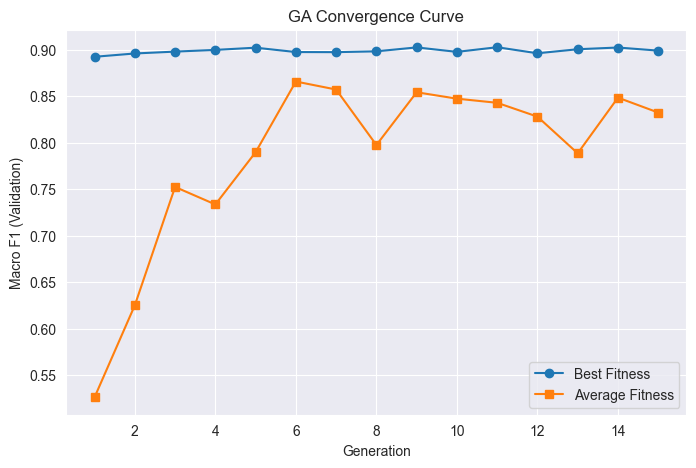

Epoch 20/150 | Loss: 0.2700 | Val Loss: 0.2967 | Val F1: 0.8864
 Early stopping at epoch 30


KeyError: 'train_f1'

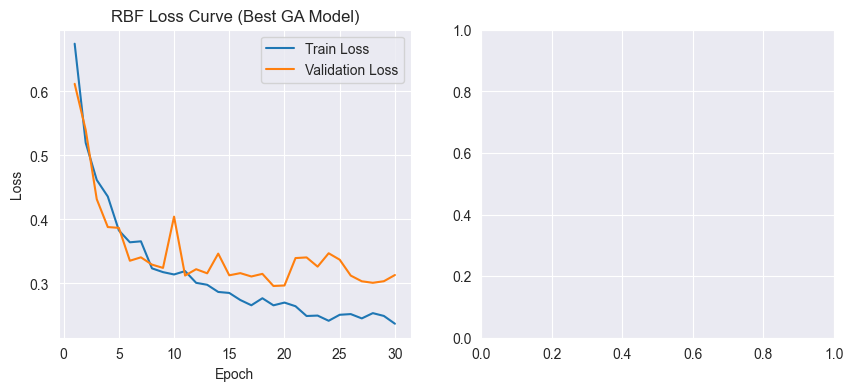

In [8]:
best_chromosome, best_fitness, history = run_genetic_algorithm()

print("\n================ FINAL RESULT ================")
print("Best Chromosome:", best_chromosome)
print("Best Validation Macro-F1:", round(best_fitness, 4))

# plot for ga algorithm.....................................................................
generations = [h["generation"] for h in history]
best_fitness = [h["best_fitness"] for h in history]
avg_fitness = [h["avg_fitness"] for h in history]

plt.figure(figsize=(8, 5))
plt.plot(generations, best_fitness, marker='o', label="Best Fitness")
plt.plot(generations, avg_fitness, marker='s', label="Average Fitness")

plt.xlabel("Generation")
plt.ylabel("Macro F1 (Validation)")
plt.title("GA Convergence Curve")
plt.legend()
plt.grid(True)

plt.show()

# plot for rbf algorithm for best situation
best_model = build_rbf_from_chromosome(
    best_chromosome,
    X_train,
    num_classes=len(np.unique(y_train))
)

history_best, val_f1, _ = train_rbf(
    best_model,
    X_train, y_train,
    X_val, y_val,
    epochs=150,
    lr=best_chromosome[5],
    batch_size=best_chromosome[6],
    patience=15,
    verbose=True
)

epochs = range(1, len(history_best["train_loss"]) + 1)

plt.figure(figsize=(10, 4))

epochs_range = range(1, len(history_best["train_loss"]) + 1)
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(epochs_range, history_best["train_loss"], label="Train Loss")
plt.plot(epochs_range, history_best["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("RBF Loss Curve (Best Model)")
plt.legend()
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(epochs_range, history_best["train_f1"], label="Train F1")
plt.plot(epochs_range, history_best["val_f1"], label="Validation F1")
plt.xlabel("Epoch")
plt.ylabel("Macro F1")
plt.title("RBF F1 Curve (Best Model)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

